# 라이브러리

In [158]:
from imports import *
%reload_ext autoreload
%autoreload 2

# 데이터셋

In [2]:
# 데이터 불러오기
df = pd.read_excel('./dataset/oecd_dataset.xlsx', index_col='Reference area')
# 결측을 제외한 183개 국가만 선택
df = df[df.notnull().all(axis=1)]

In [40]:
df.round(1)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,,
Australia,11860732.7,12063021.4,12455751.1,13723725.9,14701734.3,15461977.2,14738096.5,6112265.9,3984941.1,7525983.5,11298137.3,12870576.0
Austria,2032032.3,2138526.6,2219886.6,2289076.6,2294330.9,2556748.9,2966439.4,1041594.6,1240233.6,2078696.9,2469198.6,2682274.5
Belgium,3247814.2,3195722.8,3413040.5,3466534.3,3672222.0,3940235.8,4039798.5,2236333.8,3240717.6,3894086.3,3766052.1,3930514.0
Canada,9517376.7,10106189.4,10706255.2,11606782.6,12420954.4,13083421.6,13824361.0,5671979.1,5128085.8,9490621.0,11469309.5,12787228.3
Chile,1645285.3,1679696.5,1833572.8,1939507.5,2081471.4,2191711.5,2235390.1,1207357.4,1204832.9,1717065.8,1965011.6,2204970.0
...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,29525.4,26833.0,24494.2,22117.6,24196.7,28061.3,25512.0,5878.3,3157.2,11358.0,22313.9,11515.7
Venezuela,991198.7,715855.8,603853.4,573210.9,434663.1,400566.1,313361.9,74626.3,104650.5,193219.5,278163.1,245325.9
Viet Nam,2142564.9,2305220.9,2567449.5,3019055.6,3616451.4,4230438.4,4941541.3,1822487.4,1497054.1,2383585.2,4106124.5,3527683.0


In [41]:
df_num = df.copy()
df_num = np.log(df_num) #[years])  # 로그 변환

# 연도별 로그 성장률
growth = df_num.diff(axis=1).iloc[:, 1:]  # 2014~2024
display(growth)
print('''
연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.
''')

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,
Australia,0.016912,0.032038,0.096944,0.068839,0.050418,-0.047948,-0.880138,-0.427775,0.635839,0.406276,0.130306
Austria,0.051081,0.037339,0.030692,0.002293,0.108295,0.148626,-1.046610,0.174547,0.516441,0.172152,0.082771
Belgium,-0.016169,0.065790,0.015552,0.057642,0.070444,0.024954,-0.591357,0.370957,0.183664,-0.033432,0.042743
Canada,0.060029,0.057680,0.080761,0.067795,0.051961,0.055086,-0.890894,-0.100806,0.615572,0.189371,0.108772
Chile,0.020699,0.087653,0.056168,0.070641,0.051608,0.019733,-0.615982,-0.002093,0.354276,0.134881,0.115216
...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,-0.095619,-0.091196,-0.102060,0.089843,0.148172,-0.095241,-1.467890,-0.621560,1.280222,0.675291,-0.661496
Venezuela,-0.325436,-0.170147,-0.052078,-0.276682,-0.081692,-0.245520,-1.434865,0.338132,0.613201,0.364381,-0.125620
Viet Nam,0.073173,0.107736,0.162031,0.180549,0.156812,0.155372,-0.997475,-0.196703,0.465106,0.543874,-0.151838



연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.



In [44]:
e_hist = df.sum().to_numpy()

array([4.37964526e+08, 4.60737641e+08, 4.87061572e+08, 5.11497409e+08,
       5.39337952e+08, 5.66556710e+08, 5.85262121e+08, 2.52551012e+08,
       2.73064792e+08, 3.98042307e+08, 4.92038938e+08, 5.46034447e+08])

# 시나리오

In [6]:
# 9개 시나리오 도출
## 평균 성장률 낮음 3%, 중간 5%, 높음 7%
## 변동성 낮음 10%, 중간 20%, 높음 30%
## 3 x 3 = 9개

scenarios = []
for growth_rate in [0.03, 0.05, 0.07]:
    for volatility in [0.1, 0.2, 0.3]:
        scenarios.append((growth_rate, volatility))
scenarios_df = pd.DataFrame(scenarios, columns=['growth_rate', 'volatility'])
scenarios_df['growth_level'] = scenarios_df['growth_rate'].map({    0.03: 'L',    0.05: 'M',    0.07: 'H'})
scenarios_df['volatility_level'] = scenarios_df['volatility'].map({    0.1: 'l',    0.2: 'm',    0.3: 'h'})
scenarios_df['scenario'] = (
    'G' + scenarios_df['growth_level'] +
    '_V' + scenarios_df['volatility_level']
)
# scenarios_df = scenarios_df[['scenario', 'growth_rate', 'volatility']]
scenarios_df

,growth_rate,volatility,growth_level,volatility_level,scenario
0,0.03,0.1,L,l,GL_Vl
1,0.03,0.2,L,m,GL_Vm
2,0.03,0.3,L,h,GL_Vh
3,0.05,0.1,M,l,GM_Vl
4,0.05,0.2,M,m,GM_Vm
5,0.05,0.3,M,h,GM_Vh
6,0.07,0.1,H,l,GH_Vl
7,0.07,0.2,H,m,GH_Vm
8,0.07,0.3,H,h,GH_Vh


## 변수설정


In [62]:
# 배출량 한도 2019 emission cap 
cap = df[2019]
# 2024년 가격 2024 baseline
e0 = df[2024]
# carbon price probability distribution assumption
## based on eu-ETS historical data
## price u = 75, std = 7
carbon = {'mu': 75, 'std': 7}

In [64]:
e0 = e0.to_numpy()
e0 = e0[:, None, None, None]  # (183, 1, 1, 1)
e0.shape

(183, 1, 1, 1)

# 차원

In [ ]:
country = 183
period = 26   # 2024~2050
n_simulation = 10_0   # 시뮬레이션 수

# 시나리오
means = np.array(scenarios_df['growth_rate'])
stds = np.array(scenarios_df['volatility'])
# 이것도 가능
# # means = np.array([3, 5, 7])
# # stds  = np.array([10, 20, 30])
# # scenario_means = np.repeat(means, len(stds))   # [3,3,3,5,5,5,7,7,7]
# # scenario_stds  = np.tile(stds, len(means))     # [10,20,30,10,20,30,10,20,30]


# 성장 시나리오

In [ ]:
# 성장률 난수 생성
rng = np.random.default_rng(42)
X_rng = rng.normal(
    loc=means,
    scale=stds,
    size=(country, period, n_simulation, len(means))
)
print(X_rng.shape)
np.save('./scenario_result/X_rng_simple.npy', X_rng)

In [ ]:
# 누적 성장률과 연도별 누적 배출량
X_cumsum = np.cumsum(X_rng, axis=1)  # 누적합
X_emission = e0 * np.exp(X_cumsum)

In [68]:
# 과거 데이터 붙이기(2013~2024)
e_history = df.sum().to_numpy()
e0_global = e_history[-1]
g_history = e_history / e0_global
# g_history = g_history[:, None, None, None]  # (1, 12, 1, 1)
g_history.shape

(12,)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# years
years_hist = np.arange(2013, 2025)   # df 컬럼에 맞게 조정
years_sim  = np.arange(2025, 2051)

years = np.arange(2025, 2051)  # period=26 가정
assert len(years) == X_emission.shape[1]

# 전세계 baseline (E0 합)
E0_global = e0.reshape(-1).sum()  # e0가 (183,1,1,1)면 reshape로 1D

# 전세계 총배출량: 국가축 합
# (time, sim, scenario)
E_global = X_emission.sum(axis=0)

# 전세계 성장계수: E/E0
# (time, sim, scenario)
G = E_global / E0_global


In [ ]:
# 시나리오 3*3개
means = [0.03, 0.05, 0.07]   # 3%,5%,7%
stds  = [0.10, 0.20, 0.30]   # 10%,20%,30%

# G의 scenario 축(마지막 축)이 9개여야 함
# 시나리오 인덱스 매핑: (mu_idx, std_idx) -> k
# k = mu_idx*3 + std_idx  ( (3,10),(3,20),(3,30),(5,10)... )
def scen_idx(i_mu, j_std):
    return i_mu * len(stds) + j_std

q_low, q_high = 0.10, 0.90  # 10~90% 밴드 (원하면 0.05~0.95로 바꿔도 됨)


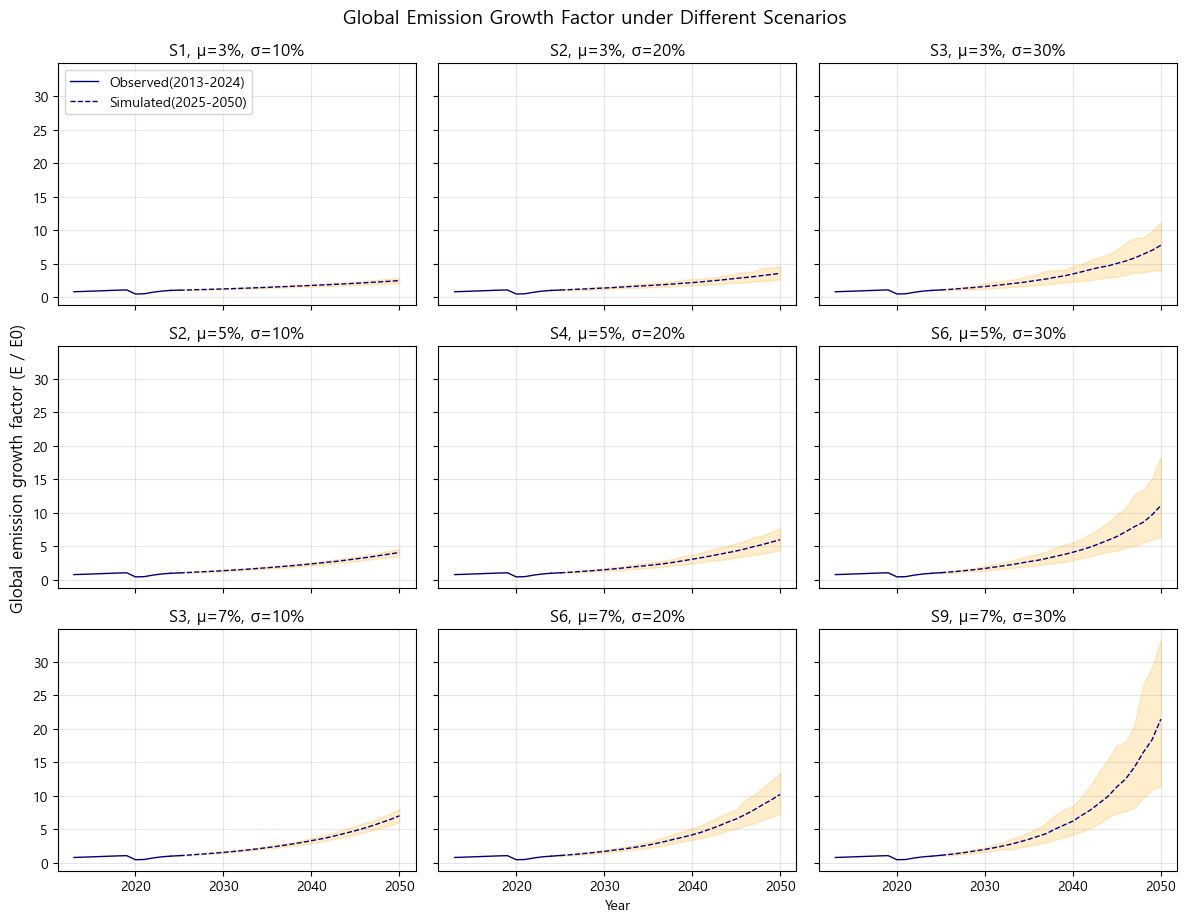

In [171]:
# 차트 그리기
fig, axes = plt.subplots(len(means), len(stds), figsize=(12, 9), sharex=True, sharey=True)

for i, mu in enumerate(means):
    for j, sd in enumerate(stds):
        ax = axes[i, j]
        k = scen_idx(i, j)

        # (time, sim)
        g_ts = G[:, :, k]

        # 연도별 요약 (time,)
        g_mean = g_ts.mean(axis=1)
        g_lo   = np.quantile(g_ts, q_low,  axis=1)
        g_hi   = np.quantile(g_ts, q_high, axis=1)

        # ① 과거 (실측)
        ax.plot(
            years_hist,
            g_history,
            color="Navy",
            label="Observed(2013-2024)"
            , linewidth=1
        )
        ax.plot(
            [2024, 2025],
            [g_history[-1], g_mean[0]],
            color="Navy", linewidth=1
        )
        # 평균선 + 밴드
        ax.plot(years_sim, g_mean, color="Navy", 
            label="Simulated(2025-2050)", linestyle='--', linewidth=1)
        ax.fill_between(years_sim, g_lo, g_hi, color='orange', alpha=0.2)

        ax.set_title(f"S{(i+1)*(j+1)}, μ={int(mu*100)}%, σ={int(sd*100)}%")
        ax.grid(True, alpha=0.3)
axes[-1, 1].set_xlabel("Year")
axes[1, 0].set_ylabel("Global emission growth factor (E / E0)", fontsize=12)
axes[0, 0].legend(loc="upper left", frameon=True)
plt.tight_layout()
fig.suptitle(
    "Global Emission Growth Factor under Different Scenarios",
    fontsize=14, y=1.02)
plt.show()


In [172]:
import numpy as np
import pandas as pd

# ===== 설정 =====
q_list = [0.10, 0.25, 0.75, 0.90]  # P10, Q1, Q3, P90
year_target = 2050

# years_sim이 예: [2025, 2026, ..., 2050] 라고 가정
# 혹시 years_sim이 numpy array든 list든 상관없음
try:
    t_idx = list(years_sim).index(year_target)
except ValueError:
    raise ValueError(f"{year_target}년이 years_sim에 없습니다. years_sim={years_sim[:5]}...")

rows = []

for i, mu in enumerate(means):
    for j, sd in enumerate(stds):
        k = scen_idx(i, j)

        # (time, sim) for scenario k
        g_ts = G[:, :, k]

        # ===== 2025년 단면: (sim,) =====
        x = g_ts[t_idx, :]

        p10, q1, q3, p90 = np.quantile(x, q_list)
        mean_ = x.mean()

        rows.append({
            "Scenario": f"S{k+1}",      # 시나리오 번호(0-based -> 1-based)
            "mu": mu,                   # 0.03 같은 값
            "sigma": sd,                # 0.10 같은 값
            "Year": year_target,
            "P10": p10,
            "Q1": q1,
            "Mean": mean_,
            "Q3": q3,
            "P90": p90,
        })

df_2025 = pd.DataFrame(rows)

# 보기 좋게 정렬(μ, σ 기준)
df_2025 = df_2025.sort_values(["mu", "sigma"]).reset_index(drop=True)

# 퍼센트 표시용(선택): 성장계수(E/E0) 그대로 두는 게 기본이고,
# %로 바꾸고 싶으면 (x-1)*100 형태를 별도 컬럼으로 만들면 됨.
display('2050년 기준 성장계수(E/E0) 분포 요약:')
display(df_2025)


'2050년 기준 성장계수(E/E0) 분포 요약:'

,Scenario,mu,sigma,Year,P10,Q1,Mean,Q3,P90
0,S1,0.03,0.1,2050,2.094109,2.239054,2.463282,2.672692,2.891715
1,S2,0.03,0.2,2050,2.659490,2.865418,3.553409,3.994571,4.640617
2,S3,0.03,0.3,2050,3.989063,5.321742,7.730251,8.496365,11.153490
3,S4,0.05,0.1,2050,3.629868,3.818724,4.102671,4.368251,4.646697
4,S5,0.05,0.2,2050,4.458590,5.061103,6.001537,6.731561,7.706075
5,S6,0.05,0.3,2050,6.480446,8.131673,11.113191,12.714568,18.358419
6,S7,0.07,0.1,2050,6.093499,6.507141,7.022229,7.436812,8.031955
7,S8,0.07,0.2,2050,7.302536,8.580882,10.220150,11.322613,13.376438
8,S9,0.07,0.3,2050,11.440581,13.472872,21.443055,24.962252,33.252315


* 여기까지 전체 합이 도출되었음
* 중간결과 같은 평균 성장률이라도 변동성이 클수록 높은 최종 성장을 보임
  

# 그룹 효과 분석

In [93]:
# Offset cost 계산
# #cap = df[2019]
# # e0 = df[2024]
# # carbon = {'mu': 75, 'std': 7}
# ## to_numpy
cap_np = cap.to_numpy().reshape(-1,1,1,1)
offset = np.maximum(X_emission - cap_np, 0)  # (183, time, sim, scenario)
offset.shape

(183, 26, 100, 9)

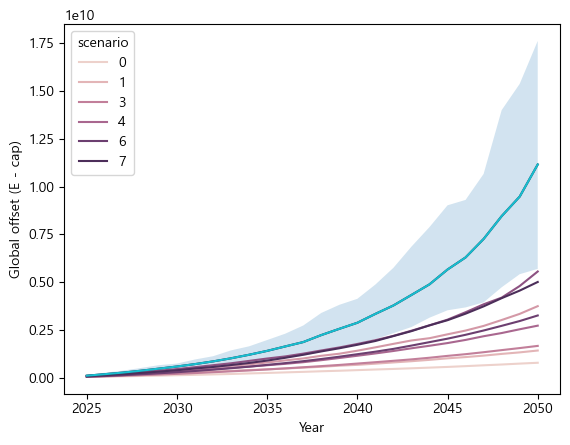

In [ ]:
# 시나리오별 carbon offset 글로벌 합산 및 연도별 평균
# (time, sim, scenario)
# E - cap 이기 때문에 E그래프와 유사한 모양새를 보임. -> 큰 차이 없음 
offset_global = offset.sum(axis=0)
offset_mean = offset_global.mean(axis=1)
# shape: (time, scenario)

import pandas as pd

years = np.arange(2025, 2051)

df_plot = (
    pd.DataFrame(offset_mean, index=years)
      .reset_index()
      .melt(id_vars="index", var_name="scenario", value_name="offset")
      .rename(columns={"index": "year"})
)
import seaborn as sns
import matplotlib.pyplot as plt
offset_q10 = np.quantile(offset_global, 0.10, axis=1)
offset_q90 = np.quantile(offset_global, 0.90, axis=1)


sns.lineplot(
    data=df_plot,
    x="year",
    y="offset",
    hue="scenario"
)
plt.plot(years, offset_mean[:, k])
plt.fill_between(years, offset_q10[:, k], offset_q90[:, k], alpha=0.2)

plt.xlabel("Year")
plt.ylabel("Global offset (E - cap)")
plt.show()


=== 탄소 상쇄 비용 도출 ===
EU ETS 역사적 데이터 기반 탄소가격 분포 가정
{'mu': 75, 'std': 7}

탄소가격 최소: 49.46111022349652
탄소가격 최대: 97.25197575557274
탄소가격 행렬: (26, 100)


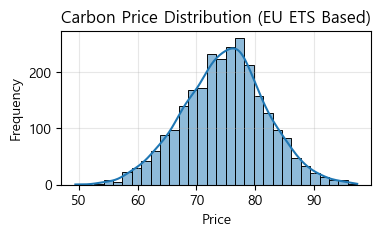

In [ ]:
# 탄소 상쇄 비용 도출 carbon offset cost
print('''=== 탄소 상쇄 비용 도출 ===''')
print('''EU ETS 역사적 데이터 기반 탄소가격 분포 가정''')
print(carbon)
# 탄소가격 난수화
rng = np.random.default_rng(42)
carbon_price = rng.normal(
    loc=carbon['mu'],
    scale=carbon['std'],
    size=(period, n_simulation)
)
carbon_price_ = carbon_price[:, :, None]  # (period, sim, 1)
print(f'''
탄소가격 최소: {carbon_price.min()}
탄소가격 최대: {carbon_price.max()}
탄소가격 행렬: {carbon_price.shape}''')
plt.figure(figsize=(4,2)), plt.grid(True, alpha=0.3)
plt.title("Carbon Price Distribution (EU ETS Based)"), plt.xlabel("Price"), plt.ylabel("Frequency")
_ = sns.histplot(carbon_price.reshape(-1), bins=30, kde=True)

In [181]:
# offset cost 계산
offset_cost = offset * carbon_price_
print(f'''
offset cost 행렬 - {offset_cost.shape}
offset cost 최소값 - {offset_cost.min()}
offset cost 최대값 - {offset_cost.max()}''')


offset cost 행렬 - (183, 26, 100, 9)
offset cost 최소값 - 0.0
offset cost 최대값 - 2567306036181.3276


## 그룹에 따른 variance reduction 실험

### 무작위 그룹 행렬 만들기

In [ ]:
# 목표 shape, 183, 20, 100
rng = np.random.default_rng(42)
X_rng = rng.uniform(
    loc=means,
    scale=stds,
    size=(country, period, n_simulation, len(means))
) 

Generator(PCG64) at 0x248EAB927A0

In [223]:
# 
def make_random_grouping_matrix(
    n_countries: int = 183,
    max_group_size: int = 20,
    n_rep: int = 100,
    seed: int = 42,
) -> np.ndarray:
    """
    Returns
    -------
    G : np.ndarray, shape (n_countries, max_group_size, n_rep), dtype int16
        G[i, s-1, r] = group id of country i when group size = s, repetition = r.
        For each (s, r):
          - countries are randomly permuted
          - partitioned into floor(n/s) groups of size s
          - the remainder (n % s) countries are all put into ONE additional group (the last group id)
    """
    rng = np.random.default_rng(seed)
    G = np.full((n_countries, max_group_size, n_rep), -1, dtype=np.int16)

    for s in range(1, max_group_size + 1):
        full_groups = n_countries // s         # number of complete groups
        rem = n_countries % s                  # remainder size
        last_gid = full_groups                 # remainder group id (only used if rem>0)

        for r in range(n_rep):
            perm = rng.permutation(n_countries)  # 183 국가 행렬(183,)

            gid = np.full(n_countries, -1, dtype=np.int16)   # group id array

            # complete groups
            for g in range(full_groups):     
                members = perm[g*s:(g+1)*s]
                gid[members] = g

            # remainder -> one group
            if rem > 0:
                members = perm[full_groups*s:]
                gid[members] = last_gid

            G[:, s-1, r] = gid

    return G

# 예시 실행
group_arr = make_random_grouping_matrix()
print(group_arr.shape)          # (183, 20, 100)
print(group_arr[:, 0, 0].max()) # s=1이면 182 (각자 1명씩 그룹)
print(group_arr[:, 1, 0].max()) # s=2이면 91 (91개 완전그룹 + 잔여(1명)그룹 = 마지막 id 91)
print(group_arr.shape)

(183, 20, 100)
182
91
(183, 20, 100)


In [225]:
# 그룹 배정 결과 확인하기
# group_arr 로 그룹 행렬을 만들었습니다.
group_arr[:, 19, 0:6]   # G[국가, 그룹크기19(20명), 강건성 반복0~5]

array([[0, 0, 5, 5, 4, 3],
       [2, 2, 6, 2, 0, 8],
       [5, 0, 3, 4, 1, 6],
       ...,
       [2, 4, 2, 1, 8, 5],
       [1, 5, 1, 5, 2, 1],
       [5, 8, 0, 2, 7, 5]], dtype=int16)

In [205]:
np.empty(183).shape

(183,)

In [157]:
# (country, sim, scenario)
offset_cost_final = offset_cost[:, -1, :, :]
print(f'''
offset cost 행렬 - {offset_cost_final.shape}
offset cost 최소값 - {offset_cost_final.min()}
offset cost 최대값 - {offset_cost_final.max()}''')


offset cost 행렬 - (183, 100, 9)
offset cost 최소값 - 0.0
offset cost 최대값 - 2567306036181.3276


In [144]:
# 차트 그리기 위한 global offset cost 계산

offset_cost_global = offset_global * carbon_price_
print(offset_cost_global.shape)
print("min cost:", offset_cost_global.min())

(26, 100, 9)
min cost: 1228830460.3851883


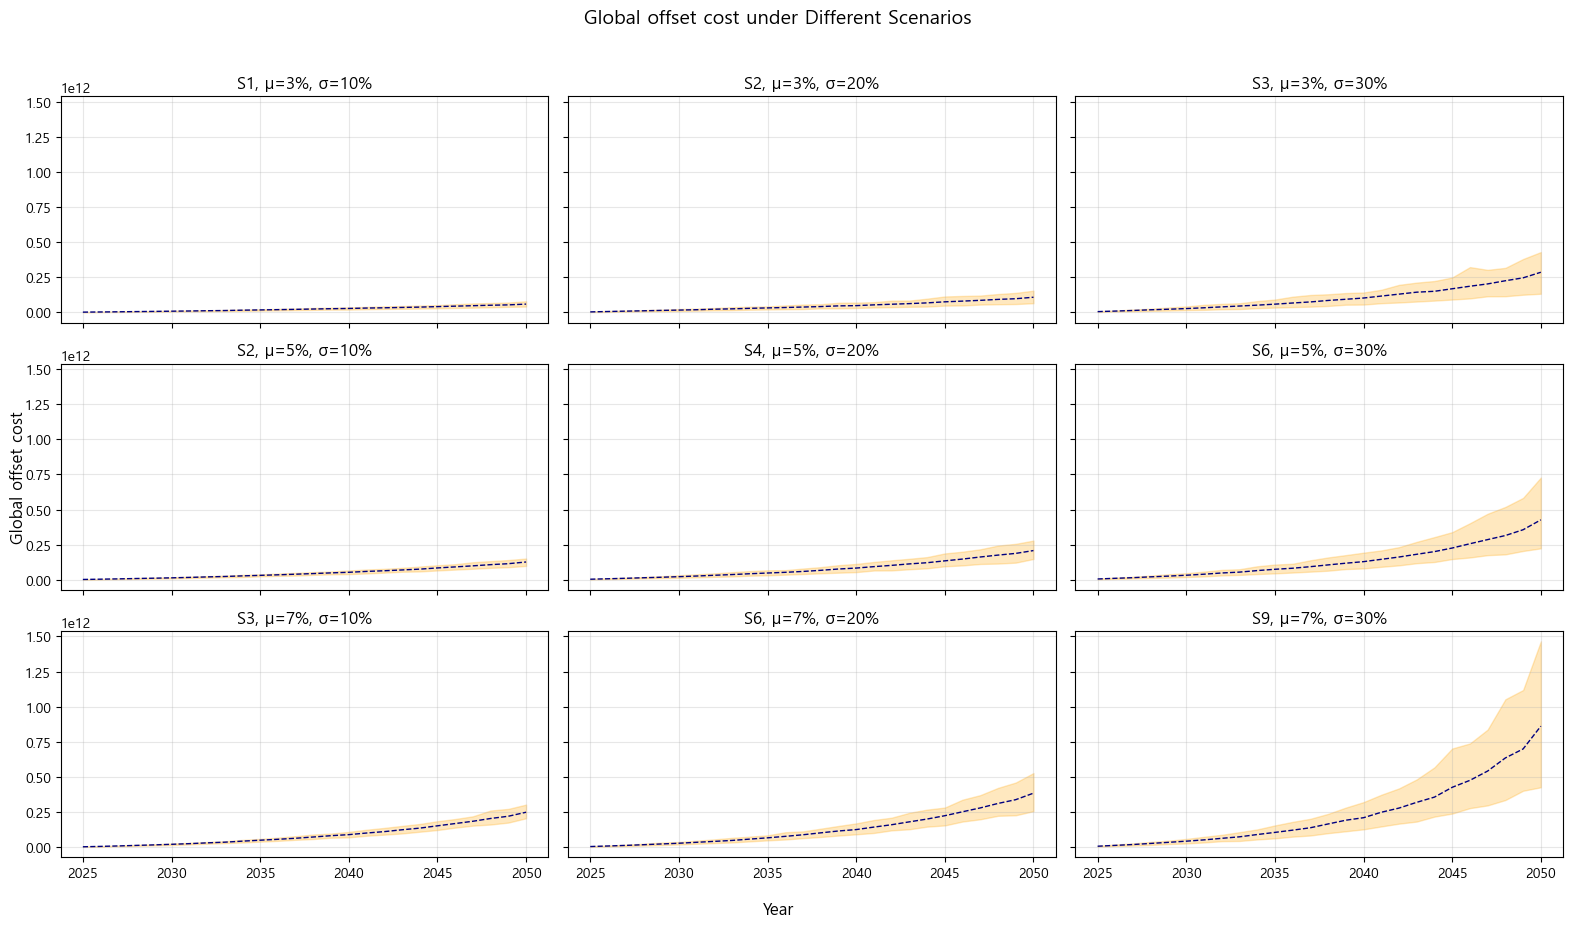

In [145]:
import matplotlib.pyplot as plt
import numpy as np

q_low, q_high = 0.10, 0.90

fig, axes = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)

for i, mu in enumerate(means):
    for j, sd in enumerate(stds):
        ax = axes[i, j]
        k = scen_idx(i, j)

        # (time, sim)
        cost_ts = offset_cost_global[:, :, k]

        # 연도별 요약
        cost_mean = cost_ts.mean(axis=1)
        cost_lo   = np.quantile(cost_ts, q_low,  axis=1)
        cost_hi   = np.quantile(cost_ts, q_high, axis=1)

        # 평균선
        ax.plot(
            years_sim,
            cost_mean,
            color="navy",
            linestyle="--",
            linewidth=1
        )

        # 불확실성 밴드
        ax.fill_between(
            years_sim,
            cost_lo,
            cost_hi,
            color="orange",
            alpha=0.25
        )

        ax.set_title(f"S{(i+1)*(j+1)}, μ={int(mu*100)}%, σ={int(sd*100)}%")
        ax.grid(True, alpha=0.3)

# 공통 라벨
fig.supxlabel("Year")
fig.supylabel("Global offset cost")
plt.tight_layout()
fig.suptitle(
    "Global offset cost under Different Scenarios",
    fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [115]:
offset_cost_country

NameError: name 'offset_cost_country' is not defined

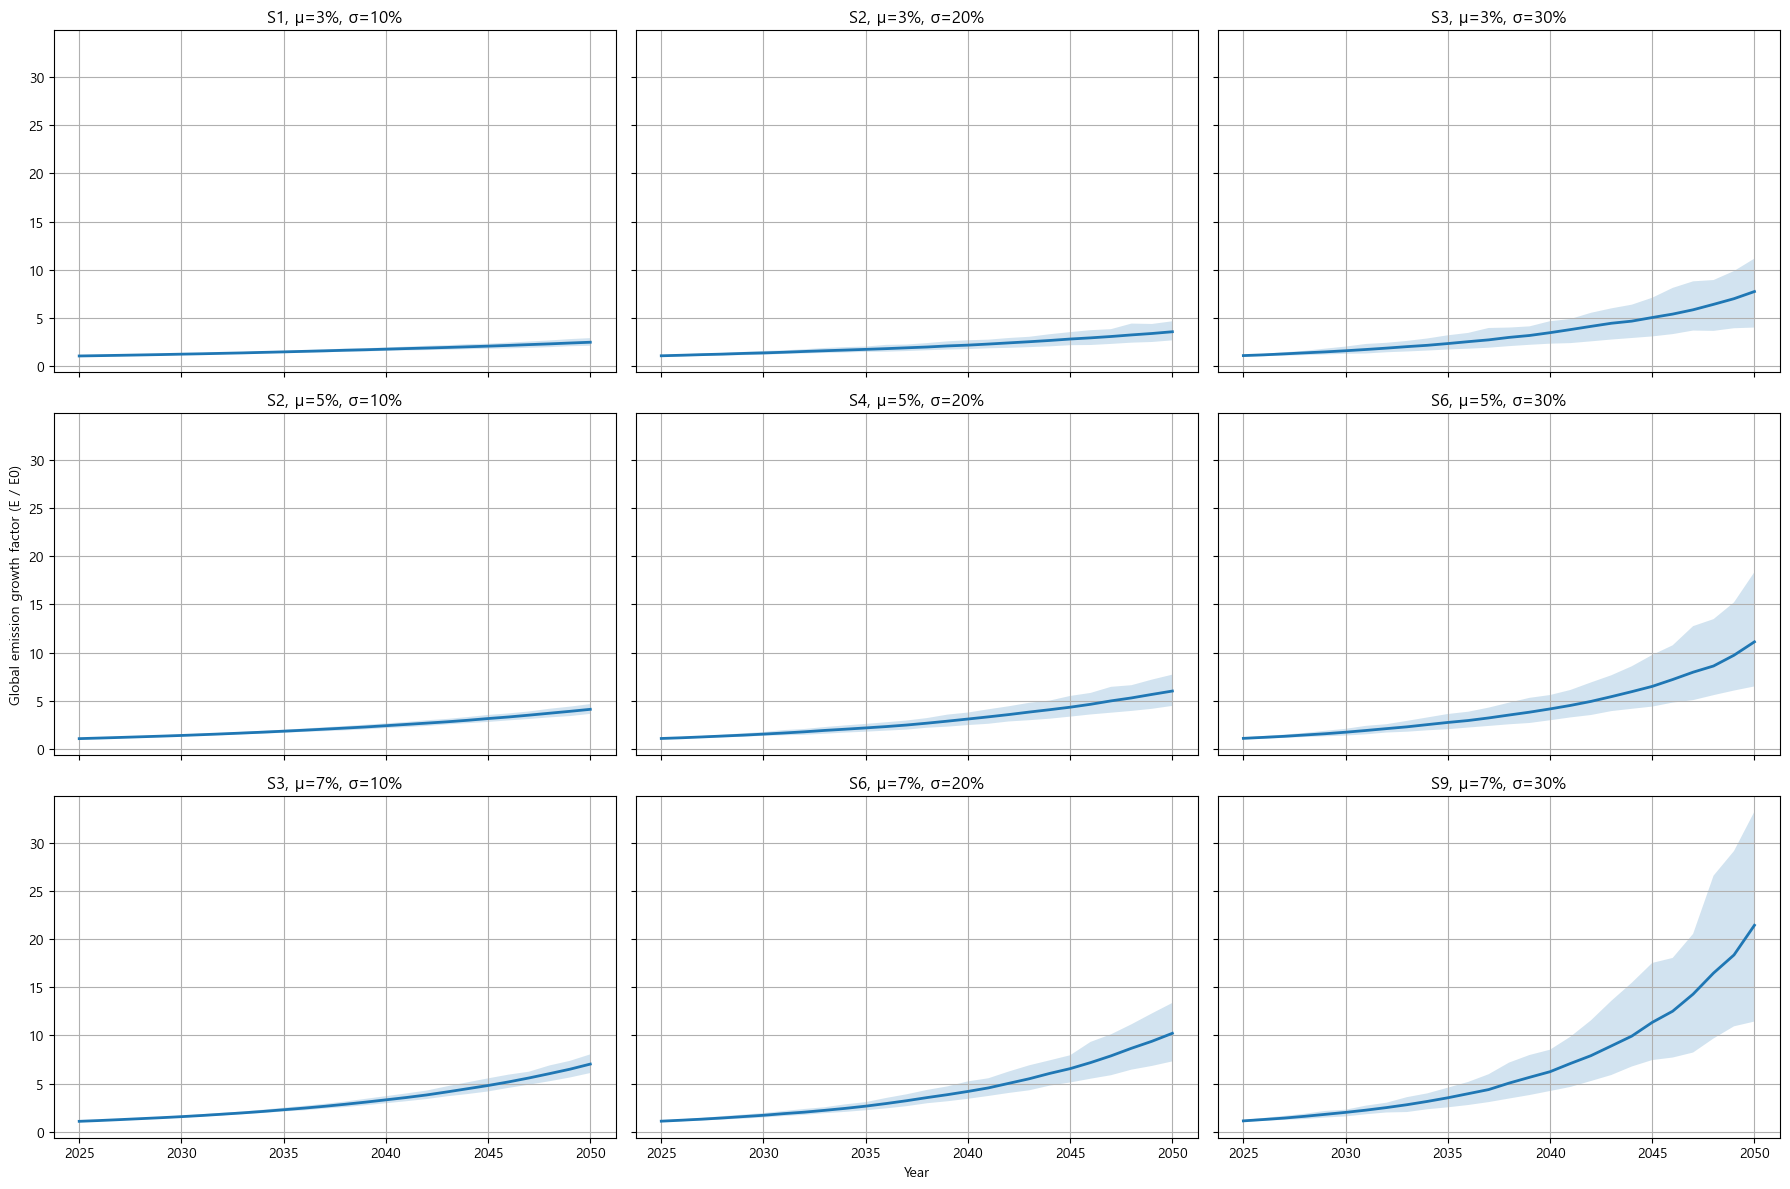

In [54]:
means = [0.03, 0.05, 0.07]   # 3%,5%,7%
stds  = [0.10, 0.20, 0.30]   # 10%,20%,30%

# G의 scenario 축(마지막 축)이 9개여야 함
# 시나리오 인덱스 매핑: (mu_idx, std_idx) -> k
# k = mu_idx*3 + std_idx  ( (3,10),(3,20),(3,30),(5,10)... )
def scen_idx(i_mu, j_std):
    return i_mu * len(stds) + j_std

q_low, q_high = 0.10, 0.90  # 10~90% 밴드 (원하면 0.05~0.95로 바꿔도 됨)

fig, axes = plt.subplots(len(means), len(stds), figsize=(18, 12), sharex=True, sharey=True)

for i, mu in enumerate(means):
    for j, sd in enumerate(stds):
        ax = axes[i, j]
        k = scen_idx(i, j)

        # (time, sim)
        g_ts = G[:, :, k]

        # 연도별 요약 (time,)
        g_mean = g_ts.mean(axis=1)
        g_lo   = np.quantile(g_ts, q_low,  axis=1)
        g_hi   = np.quantile(g_ts, q_high, axis=1)

        # 평균선 + 밴드
        ax.plot(years, g_mean, linewidth=2)
        ax.fill_between(years, g_lo, g_hi, alpha=0.2)

        ax.set_title(f"S{(i+1)*(j+1)}, μ={int(mu*100)}%, σ={int(sd*100)}%")
        ax.grid(True)
axes[-1, 1].set_xlabel("Year")
axes[1, 0].set_ylabel("Global emission growth factor (E / E0)")

plt.tight_layout()
plt.show()


In [136]:
offset.shape

(183, 26, 100, 9)

In [38]:
print(G.shape)

(26, 100, 9)


# 

In [ ]:
# 시나리오별로 몬테카를로 시뮬레이션
n_years = df.shape[1]
n_simulations = 10000
results = {}
for idx, row in scenarios_df.iterrows():
    growth_rate = row['growth_rate']
    volatility = row['volatility']
    
    simulations = []
    for _ in range(n_simulations):
        yearly_changes = np.random.normal(loc=growth_rate, scale=volatility, size=n_years-1)
        simulation = [df.mean().iloc[0]]  # 시작값은 현재 평균 배출량
        for change in yearly_changes:
            next_value = simulation[-1] * (1 + change)
            simulation.append(next_value)
        simulations.append(simulation)
    
    results[(growth_rate, volatility)] = np.array(simulations)


In [72]:
# 2019 baseline
cap = df[2019]
# 2024 baseline
E0 = df[2024]

In [ ]:
# 시뮬레이션 함수


In [67]:
df[2024]

Reference area
Australia    1.287058e+07
Austria      2.682275e+06
Belgium      3.930514e+06
Canada       1.278723e+07
Chile        2.204970e+06
                 ...     
Vanuatu      1.151575e+04
Venezuela    2.453259e+05
Viet Nam     3.527683e+06
Zambia       1.710086e+05
Zimbabwe     1.334519e+05
Name: 2024, Length: 183, dtype: float64

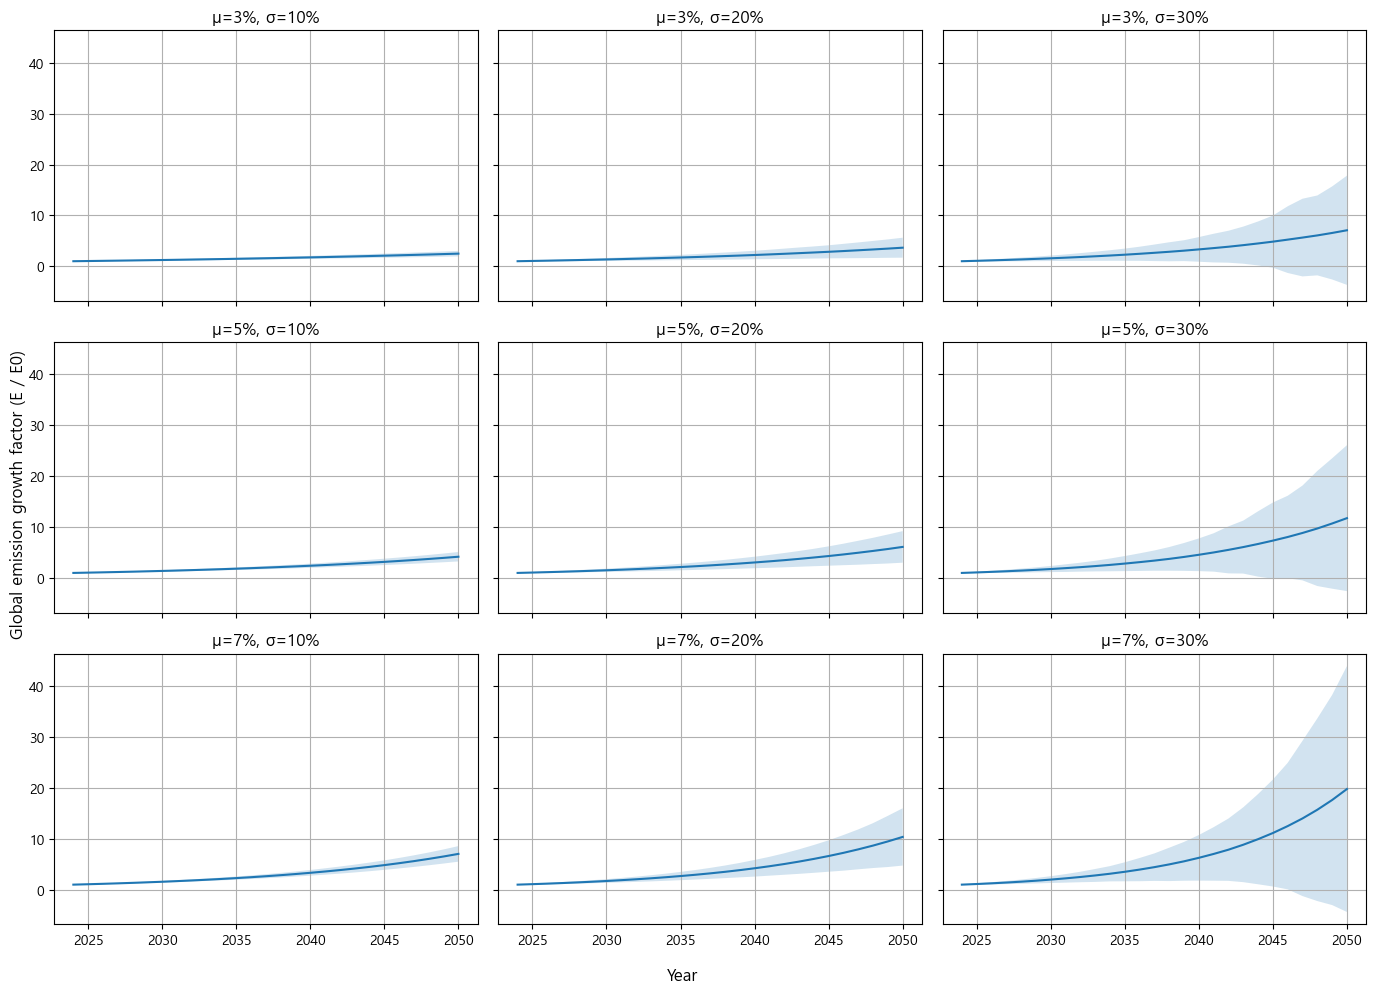

In [76]:
# gpt ver
import numpy as np
import matplotlib.pyplot as plt

def simulate_global_emissions_country_iid(
    E0, mu, sigma,
    years=26, n_sims=10_000, seed=42
):
    """
    E0: pd.Series (국가별 2024 배출량)  <-- 핵심
    g_{i,t} iid ~ N(mu, sigma), 국가 간 독립, 시간도 독립
    return global_E: (S, T+1)  # t=0 포함
    """
    rng = np.random.default_rng(seed)

    E0 = E0.sort_index().astype(float)
    E0_vec = E0.to_numpy()
    N = len(E0_vec)
    S = n_sims
    T = years

    # g: (S, T, N)  모든 국가에 동일한 mu, sigma지만 샘플은 독립
    g = rng.normal(loc=mu, scale=sigma, size=(S, T, N))

    # 누적 로그성장률
    cum = np.cumsum(g, axis=1)  # (S,T,N)

    # 배출량 경로: E_{i,t} = E0_i * exp(sum g)
    E = np.empty((S, T+1, N), dtype=float)
    E[:, 0, :] = E0_vec[None, :]
    E[:, 1:, :] = E0_vec[None, None, :] * np.exp(cum)

    # 전세계 합
    global_E = E.sum(axis=2)  # (S,T+1)
    return global_E


def plot_3x3_scenarios_global_growth(
    E0,
    mus=(0.03, 0.05, 0.07),
    sigmas=(0.10, 0.20, 0.30),
    start_year=2024,
    years=26,
    n_sims=10_000,
    seed=42,
    y_as_growth_factor=True,  # True면 E/E0(성장지수), False면 절대배출
):
    x = np.arange(start_year, start_year + years + 1)
    fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

    for i, mu in enumerate(mus):
        for j, sigma in enumerate(sigmas):
            ax = axes[i, j]

            global_E = simulate_global_emissions_country_iid(
                E0=E0, mu=mu, sigma=sigma,
                years=years, n_sims=n_sims,
                seed=seed + i*100 + j
            )

            if y_as_growth_factor:
                y = global_E / global_E[:, [0]]
                y_label = "Global emission growth factor (E / E0)"
            else:
                y = global_E
                y_label = "Global emissions"

            mean = y.mean(axis=0)
            std  = y.std(axis=0, ddof=1)
            lower = mean - 1.96 * std
            upper = mean + 1.96 * std

            ax.plot(x, mean)
            ax.fill_between(x, lower, upper, alpha=0.2)
            ax.set_title(f"μ={mu:.0%}, σ={sigma:.0%}")
            ax.grid(True)

    fig.supxlabel("Year")
    fig.supylabel(y_label)
    fig.tight_layout()
    return fig


# ===== 실행 =====
E0 = df[2024]  # 너가 강조한 부분: 초기값은 국가별!
fig = plot_3x3_scenarios_global_growth(
    E0=E0,
    mus=(0.03, 0.05, 0.07),
    sigmas=(0.10, 0.20, 0.30),
    start_year=2024,
    years=26,       # 2024~2050
    n_sims=10_000,
    y_as_growth_factor=True
)
plt.show()


KeyboardInterrupt: 

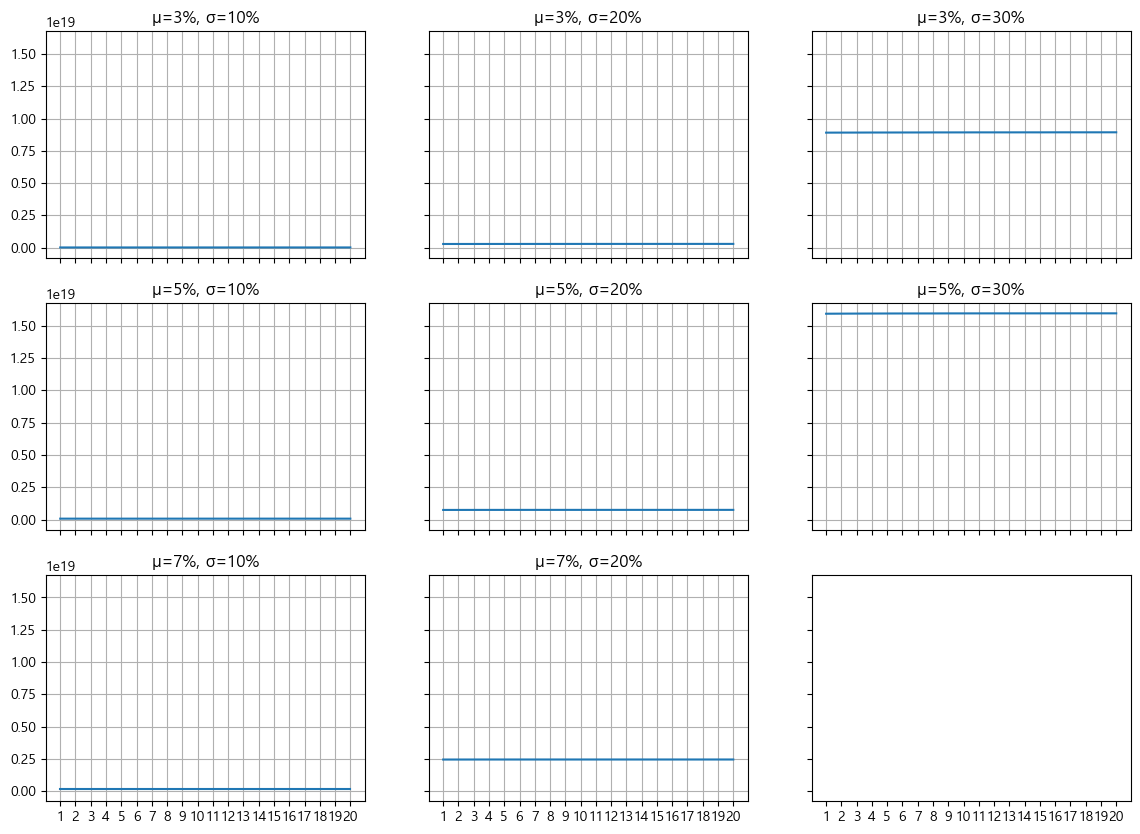

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_terminal_emissions(
    E0, mu, sigma,
    years=26, n_sims=10_000, seed=42
):
    """
    국가별 초기배출 E0(2024)에서 출발, 로그성장률 iid ~ N(mu, sigma)로
    최종연도(2024+years)의 국가별 배출량 E_{i,T}를 시뮬레이션.

    return:
      E_T: (S, N)  # terminal emissions per country
    """
    rng = np.random.default_rng(seed)

    # 인덱스 정렬 통일
    E0 = E0.sort_index().astype(float)
    E0_vec = E0.to_numpy()
    N = len(E0_vec)
    S = n_sims
    T = years

    # g: (S,T,N) 국가별/시간별 독립
    g = rng.normal(loc=mu, scale=sigma, size=(S, T, N))
    cum = np.sum(g, axis=1)  # (S,N)  최종시점까지 누적 로그성장률

    E_T = E0_vec[None, :] * np.exp(cum)  # (S,N)
    return E_T


def variance_by_group_size(
    E_T, cap,
    s_max=20, seed=123
):
    """
    E_T: (S, N) terminal emissions
    cap: (N,) array-like (pd.Series든 np.ndarray든 OK)
         단, E_T의 열 순서와 같은 국가 순서로 정렬되어 있어야 함
    """
    rng = np.random.default_rng(seed)

    cap_vec = np.asarray(cap, dtype=float)  # ✅ Series/ndarray 모두 수용
    S, N = E_T.shape

    if cap_vec.shape[0] != N:
        raise ValueError(f"cap 길이({cap_vec.shape[0]}) != 국가 수 N({N}). "
                         f"E0/cap 정렬이 어긋났을 가능성 큼.")

    s_arr = np.arange(1, s_max + 1)
    var_arr = np.zeros(s_max, dtype=float)

    for s in s_arr:
        world_offset = np.zeros(S, dtype=float)

        for k in range(S):
            perm = rng.permutation(N)
            E_perm = E_T[k, perm]
            cap_perm = cap_vec[perm]

            for start in range(0, N, s):
                end = min(start + s, N)
                E_g = E_perm[start:end].sum()
                cap_g = cap_perm[start:end].sum()
                world_offset[k] += max(E_g - cap_g, 0.0)

        var_arr[s - 1] = np.var(world_offset, ddof=1)

    return s_arr, var_arr


def plot_3x3_variance_vs_group_size(
    E0, cap,
    mus=(0.03, 0.05, 0.07),
    sigmas=(0.10, 0.20, 0.30),
    years=26, n_sims=10_000,
    s_max=20,
    seed_sim=42,
    seed_group=123
):
    """
    9개 시나리오(μ×σ)에 대해,
    그룹 사이즈 s=1..s_max의 world offset 분산을 계산하고 3×3 subplot으로 그림.
    """
    # ✅ 인덱스 정렬 통일 (E_T 열 순서와 cap 순서가 같아야 함)
    E0 = E0.sort_index().astype(float)
    cap = cap.reindex(E0.index).astype(float)

    cap_vec = cap.to_numpy()  # 여기서만 ndarray로 만들고, 이후 고정 사용

    fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

    for i, mu in enumerate(mus):
        for j, sigma in enumerate(sigmas):
            ax = axes[i, j]

            # terminal emissions
            E_T = simulate_terminal_emissions(
                E0=E0, mu=mu, sigma=sigma,
                years=years, n_sims=n_sims,
                seed=seed_sim + i*100 + j
            )

            # variance vs group size
            s_arr, var_arr = variance_by_group_size(
                E_T=E_T,
                cap=cap_vec,             # ✅ cap을 ndarray로 줘도 함수가 처리함
                s_max=s_max,
                seed=seed_group + i*100 + j
            )

            ax.plot(s_arr, var_arr)
            ax.set_title(f"μ={mu:.0%}, σ={sigma:.0%}")
            ax.set_xticks(np.arange(1, s_max + 1, 1))
            ax.grid(True)

    fig.supxlabel("Group size s (members per group)")
    fig.supylabel("Variance of world offset obligation at terminal year")
    fig.tight_layout()
    return fig


# ===== 실행 =====
E0 = df[2024]   # ✅ 초기값(국가별) 잊지 말기
cap = df[2019]  # ✅ 정책 기준선

fig = plot_3x3_variance_vs_group_size(
    E0=E0, cap=cap,
    mus=(0.03, 0.05, 0.07),
    sigmas=(0.10, 0.20, 0.30),
    years=26,        # 2024->2050
    n_sims=10000,
    s_max=20
)
plt.show()


2393248.77492915

In [61]:
# 결과 시각화
results[(0.05, 0.2)]  # 예시: 성장률 5%, 변동성 20%

array([[2393248.77492915, 2761762.69110248, 2563464.99651982, ...,
        2409856.63991153, 1775109.51264842, 2309351.57171951],
       [2393248.77492915, 2040897.26646689, 1545392.11794332, ...,
        2677300.91640472, 2607500.13501771, 1840110.6443172 ],
       [2393248.77492915, 2999665.46734284, 3645974.80607252, ...,
        2133498.9703775 , 2367106.85430591, 3178513.24827221],
       ...,
       [2393248.77492915, 2938308.28962825, 2944564.56574063, ...,
         954653.68543994,  784242.55579879,  881810.03842058],
       [2393248.77492915, 2228044.84222365, 1918484.09759701, ...,
        1183813.83190959, 1101172.97198419, 1054028.88517292],
       [2393248.77492915, 2801246.16738892, 2535595.72095505, ...,
        3568023.38703352, 2366181.7532144 , 2602924.65223364]])

In [39]:
df_num = df.copy()

# 연도별 변동성 차이 
growth = np.log(df_num)
growth = growth.pct_change(axis=1).iloc[:, 1:]  # 2014~2024
display(growth)
print(f'''
연도별  성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.
''')
display(pd.DataFrame({'mean': growth.mean(), 'std': growth.std(ddof=1)}).round(5).T)

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,
Australia,0.001038,0.001965,0.005934,0.004189,0.003055,-0.002896,-0.053322,-0.027376,0.041837,0.025659,0.008024
Austria,0.003517,0.002562,0.002100,0.000157,0.007394,0.010073,-0.070229,0.012597,0.036808,0.011834,0.005623
Belgium,-0.001078,0.004393,0.001034,0.003828,0.004660,0.001643,-0.038875,0.025373,0.012251,-0.002203,0.002823
Canada,0.003736,0.003576,0.004989,0.004168,0.003181,0.003362,-0.054184,-0.006482,0.039842,0.011787,0.006692
Chile,0.001446,0.006115,0.003895,0.004879,0.003547,0.001352,-0.042133,-0.000149,0.025302,0.009395,0.007951
...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,-0.009290,-0.008943,-0.010099,0.008981,0.014679,-0.009299,-0.144664,-0.071616,0.158887,0.072319,-0.066064
Venezuela,-0.023571,-0.012621,-0.003912,-0.020868,-0.006293,-0.019032,-0.113382,0.030136,0.053052,0.029937,-0.010021
Viet Nam,0.005020,0.007354,0.010979,0.012101,0.010384,0.010183,-0.064716,-0.013645,0.032710,0.037038,-0.009971



연도별  성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.



,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
mean,0.00181,0.00336,0.00569,0.00583,0.00453,-0.00508,-0.07057,0.01335,0.03501,0.02338,0.00534
std,0.01871,0.01401,0.01835,0.01098,0.00891,0.03950,0.02839,0.04410,0.04658,0.06698,0.01640


In [ ]:

display(pd.DataFrame({'mean': growth.mean(), 'std': growth.std(ddof=1)}).round(5).T)

* 결측을 제외한 183개를 대상으로 분석함

In [27]:
# 전체 풀링 (NaN 제거)
all_growth = growth.values.flatten()

overall_mean = all_growth.mean()
overall_var  = all_growth.var(ddof=1)  # 표본분산
overall_std  = all_growth.std(ddof=1)

print(f'''전체 연도별 로그 성장률의 평균: {overall_mean:.5f}
전체 연도별 로그 성장률의 분산: {overall_var:.5f}
전체 연도별 로그 성장률의 표준편차: {overall_std:.5f}''')


전체 연도별 로그 성장률의 평균: 0.01598
전체 연도별 로그 성장률의 분산: 0.21149
전체 연도별 로그 성장률의 표준편차: 0.45988


In [81]:
pd.DataFrame({'mean': growth.mean(), 'std': growth.std(ddof=1)}).round(5).T

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
mean,0.00181,0.00336,0.00569,0.00583,0.00453,-0.00508,-0.07057,0.01335,0.03501,0.02338,0.00534
std,0.01871,0.01401,0.01835,0.01098,0.00891,0.03950,0.02839,0.04410,0.04658,0.06698,0.01640


In [80]:
country_means = growth.drop(columns=[2020]).mean(axis=1)
country_means.mean(), country_means.std(ddof=1)

(0.10792075367109275, 0.08199010593961072)

In [87]:
all_growth_wo_2020 = (
    # 격리
    growth.drop(columns=[2020, 2021, 2022, 2023])
    .values.flatten()
)
all_growth_wo_2020 = all_growth_wo_2020[~np.isnan(all_growth_wo_2020)]

print(f'''전체 연도별 로그 성장률 (2020년 제외)의 평균: {all_growth_wo_2020.mean():.5f}
전체 연도별 로그 성장률 (2020년 제외)의 분산: {all_growth_wo_2020.var(ddof=1):.5f}
전체 연도별 로그 성장률 (2020년 제외)의 표준편차: {all_growth_wo_2020.std(ddof=1):.5f}''')


전체 연도별 로그 성장률 (2020년 제외)의 평균: 0.03812
전체 연도별 로그 성장률 (2020년 제외)의 분산: 0.07066
전체 연도별 로그 성장률 (2020년 제외)의 표준편차: 0.26582


mean 0.015983465076052226 std 0.45988452886725434
skew -1.9976692684603798 kurtosis(excess) 38.128679047017414


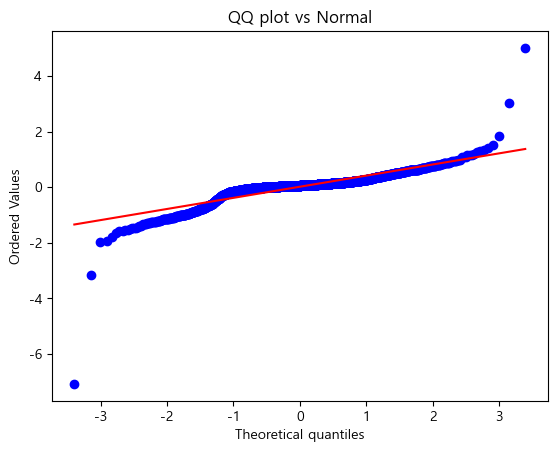

In [57]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

x = growth.values.flatten()
x = x[~np.isnan(x)]

print("mean", x.mean(), "std", x.std(ddof=1))
print("skew", stats.skew(x), "kurtosis(excess)", stats.kurtosis(x))  # excess=0이면 정규

# QQ plot (정규 기준)
stats.probplot(x, dist="norm", plot=plt)
plt.title("QQ plot vs Normal")
plt.show()


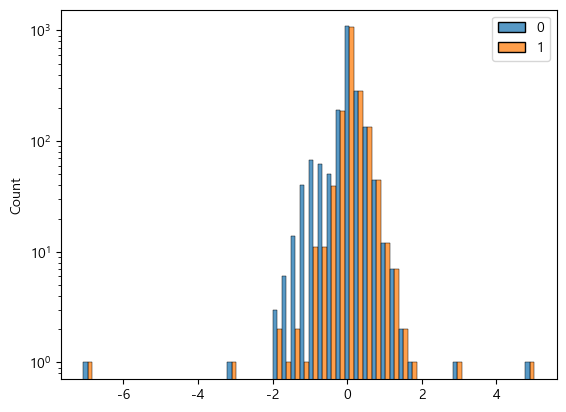

In [ ]:
sns.histplot([x,all_growth_wo_2020], bins=50, multiple='dodge')
plt.yscale('log')

In [94]:
x = growth.values.flatten()
summary = pd.DataFrame([{
    'Min': np.min(x),
    'Q1': np.percentile(x, 25),
    'Mean': np.mean(x),
    'Median': np.median(x),
    'Q3': np.percentile(x, 75),
    'Max': np.max(x),
    'Std': np.std(x, ddof=1)
}])
(summary*100).round(3)


,Min,Q1,Mean,Median,Q3,Max,Std
0,-708.132,-3.399,1.598,5.993,17.081,501.254,45.988


* 연구결과 첫번쨰 figure에 작성함  
* 성장률 데이터입니다.  
Min	Q1	Mean	Median	Q3	Max	Std  
0	-7.081323	-0.033992	0.015983	0.059929	0.170811	5.012535	0.459885  

In [105]:
x2019 = pd.to_numeric(df[2019], errors="coerce").dropna()

cap_2019_stats = pd.DataFrame([{
    "Baseline Year": 2019,
    "N": len(x2019),
    "Min": x2019.min(),
    "Q1": x2019.quantile(0.25),
    "Mean": x2019.mean(),
    "Median": x2019.median(),
    "Q3": x2019.quantile(0.75),
    "Max": x2019.max(),
    "Std. Dev.": x2019.std(ddof=1),
}])

cap_2019_stats.round(0)

,Baseline Year,N,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
0,2019,183,3271.0,110435.0,3198154.0,409384.0,2158524.0,81575829.0,8362697.0


<Axes: xlabel='2019', ylabel='Count'>

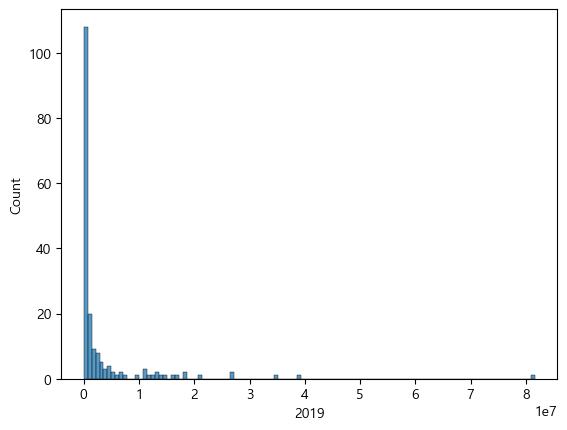

In [104]:
sns.histplot(df[2019])
# plt.xscale('log')

In [112]:
e_cap = df[2019].sum()
df.columns
for i in df.columns:
    print(f'{i}년: {df[i].sum() - e_cap}')

2013년: -147297594.70523357
2014년: -124524479.10950053
2015년: -98200548.03145301
2016년: -73764711.60764265
2017년: -45924168.50533974
2018년: -18705410.644227862
2019년: 0.0
2020년: -332711108.31636906
2021년: -312197328.7960069
2022년: -187219813.15386552
2023년: -93223182.03733599
2024년: -39227673.819178104


In [113]:
e_cap = df[2019]
df.columns
for i in df.columns:
    emission_offset = (df[i] - e_cap).clip(lower=0)
    print(f'{i}년: {emission_offset.sum()}')

2013년: 7956378.718986341
2014년: 8893371.302678265
2015년: 9334127.933080701
2016년: 11207080.606447073
2017년: 12913800.70333068
2018년: 15739436.766790904
2019년: 0.0
2020년: 36788.9955828251
2021년: 181454.04160164177
2022년: 1500065.6503684893
2023년: 6802136.674289644
2024년: 16375124.588879216


# 시뮬레이션

In [ ]:
# 성장률 통계
g_mean, g_std = summary['Mean'], summary['Std']
g_mean, g_std

(0    0.015983
 Name: Mean, dtype: float64,
 0    0.459885
 Name: Std, dtype: float64)

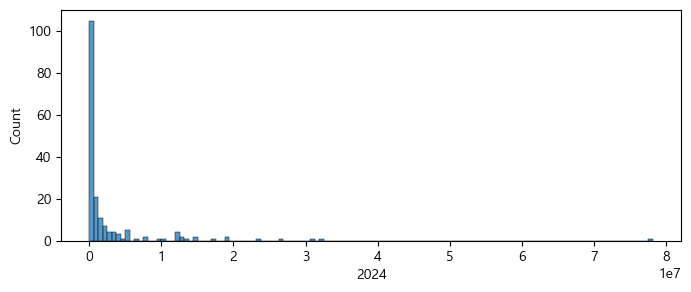

(<Figure size 800x300 with 1 Axes>,
 <Axes: xlabel='2024', ylabel='Count'>,
 None)

In [134]:
# 배출량 초기값, E_0 시점
e_0 = df[2024]
plt.figure(figsize=(8,3)), sns.histplot(e_0), plt.show()

In [141]:
# 시나리오 설정
random_seed = 42
np.random.seed(random_seed)
n = 10_000
start_year = 2024
end_year = 2050
years = end_year - start_year
n_country = len(df.index)

In [142]:
g_sim = np.random.normal(
    loc=g_mean,
    scale=g_std,
    size=(n, n_country, years)
)
g_sim.shape

(10000, 183, 26)

In [143]:
g_sim[:, :, 0]

array([[ 0.24441462, -0.51334067, -0.29532249, ..., -0.09038826,
         0.66301099, -0.46511144],
       [-0.29003395,  1.28306548,  0.36388076, ...,  0.39623376,
         0.26285292,  0.11225977],
       [ 0.86578891,  0.37614463,  1.0076553 , ...,  0.07933642,
         0.44047226,  0.24009125],
       ...,
       [-0.30731368,  0.51700207,  0.64412471, ...,  0.97897078,
         0.7665995 ,  0.24452306],
       [ 0.39063383, -0.68764138,  0.24042284, ..., -0.50140498,
        -0.115849  ,  0.20320375],
       [ 0.19288209,  0.29355524, -0.18216327, ..., -0.34861975,
        -0.42303639,  0.92551286]])

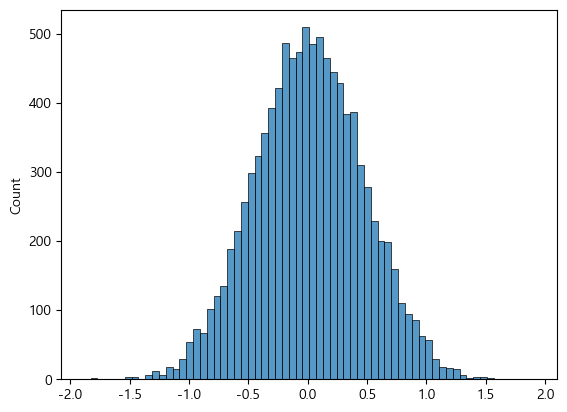

(<Axes: ylabel='Count'>, None)

In [159]:
sample = np.random.choice(g_sim.flatten(), size=10_000, replace=False)
sns.histplot(sample), plt.show()

In [155]:
# 누적 성장률
cumulative_growth = np.cumsum(g_sim, axis=2)
cumulative_growth.shape

(10000, 183, 26)

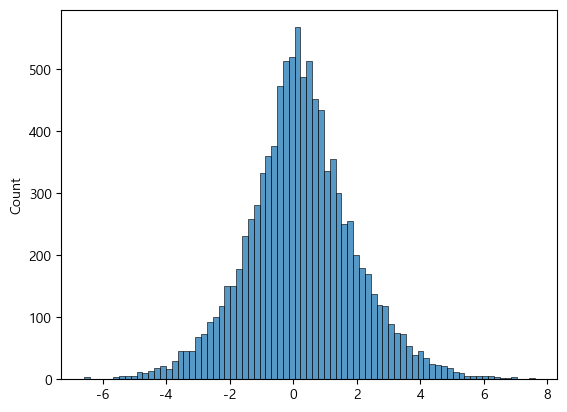

In [160]:
sample = np.random.choice(cumulative_growth.flatten(), size=10_000, replace=False)
sns.histplot(sample)
plt.show()

In [161]:
# 배출량
emissions = e_0.values[np.newaxis, :, np.newaxis] * np.exp(cumulative_growth)
emissions.shape

(10000, 183, 26)

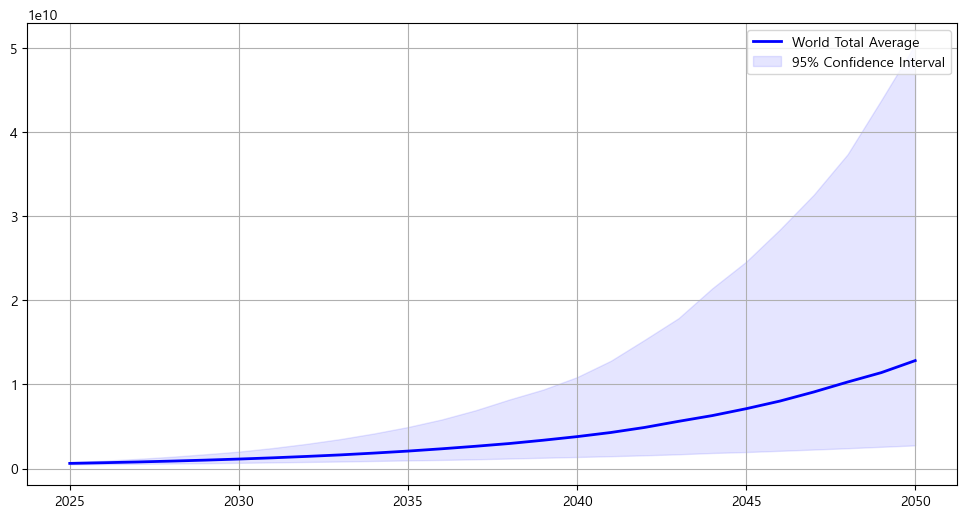

In [164]:
# 1. 모든 시나리오(s)와 국가(i)에 대해 연도별(t)로 합산 후 평균
# emissions shape: (10000, 193, 50)
# world_total_per_scenario: (10000, 50) -> 각 시나리오별 지구 전체 배출량
world_total_per_scenario = np.sum(emissions, axis=1)

# world_average_path: (50,) -> 10,000개 시나리오의 평균적인 지구 배출량 경로
world_average_path = np.mean(world_total_per_scenario, axis=0)

# world_average_path의 실제 길이에 맞춰 years_range를 생성합니다.
actual_years_count = world_average_path.shape[0]

# 초기 연도가 2025년이라면:
years_range = np.arange(2025, 2025 + actual_years_count)

# 이제 다시 그려보세요!
plt.figure(figsize=(12, 6))
plt.plot(years_range, world_average_path, color='blue', lw=2, label='World Total Average')

# 신뢰구간도 동일한 길이를 사용하게 됩니다.
upper_bound = np.percentile(world_total_per_scenario, 97.5, axis=0)
lower_bound = np.percentile(world_total_per_scenario, 2.5, axis=0)
plt.grid(True)
plt.fill_between(years_range, lower_bound, upper_bound, color='blue', alpha=0.1, label='95% Confidence Interval')
plt.legend()
plt.show()

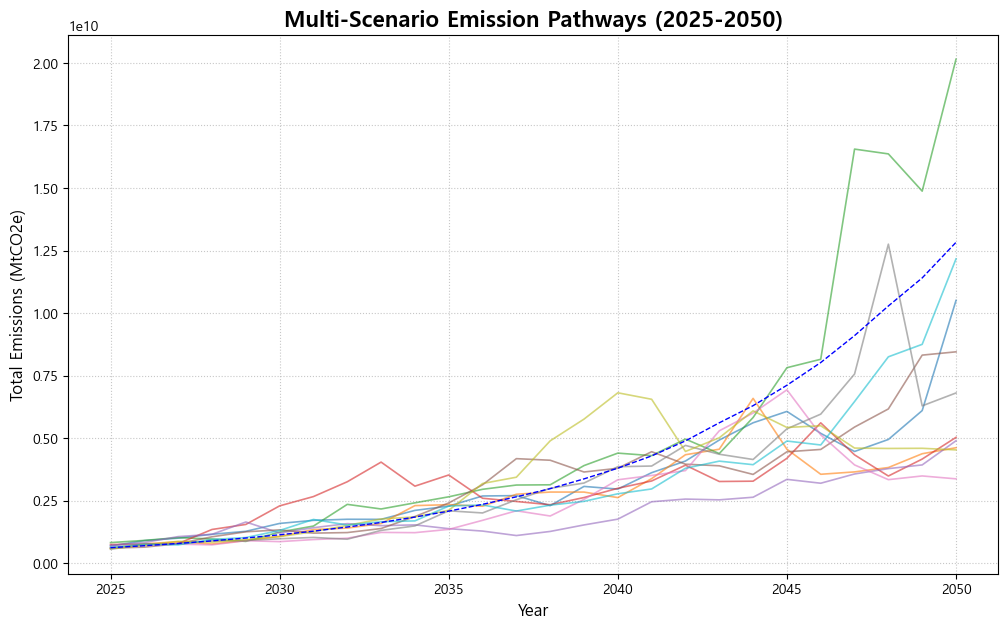

In [182]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 실제 데이터 길이에 맞게 연도 설정
actual_years_count = world_average_path.shape[0]
years_range = np.arange(2025, 2025 + actual_years_count)

plt.figure(figsize=(12, 7))

# 2. 개별 시나리오 n개 (다양한 색상으로 역동성 부여)
# 컬러맵을 사용하여 n개의 서로 다른 색상을 생성합니다.
n = 10
colors = plt.cm.tab10(np.linspace(0, 1, n)) 

for i in range(n):
    plt.plot(years_range, world_total_per_scenario[i, :actual_years_count], 
             lw=1.2, alpha=0.6, color=colors[i], 
             label=f'Scenario {i+1}')

# 3. 신뢰구간 (부드러운 연두색 계열로 배경 처리)
upper_bound = np.percentile(world_total_per_scenario, 97.5, axis=0)
lower_bound = np.percentile(world_total_per_scenario, 2.5, axis=0)

# plt.fill_between(years_range, lower_bound[:actual_years_count], upper_bound[:actual_years_count], 
#                  color='limegreen', alpha=0.15, label='95% Confidence Interval')

# 4. 전체 평균선 (가장 눈에 띄는 굵은 검정색 점선)
plt.plot(years_range, world_average_path, color='blue', lw=1, ls='--', label='World Average Trend')

# 그래프 꾸미기
plt.title('Multi-Scenario Emission Pathways (2025-2050)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Emissions (MtCO2e)', fontsize=12)

# 범례를 그래프 밖으로 빼서 시나리오 라벨이 겹치지 않게 합니다.
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)

# plt.tight_layout() # 범례가 잘리지 않도록 조정
plt.show()